##### Cellule 1 : Imports et rechargement du DataFrame maître

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# Rechargement rapide
train    = pd.read_csv('../data/train.csv',           parse_dates=['date'])
stores   = pd.read_csv('../data/stores.csv')
holidays = pd.read_csv('../data/holidays_events.csv', parse_dates=['date'])
oil      = pd.read_csv('../data/oil.csv',             parse_dates=['date'])
transac  = pd.read_csv('../data/transactions.csv',    parse_dates=['date'])

# Fusion
df = train.merge(stores, on='store_nbr', how='left')
df = df.merge(transac,   on=['date','store_nbr'],  how='left')
df = df.merge(oil,       on='date',                how='left')

hol = holidays[holidays['transferred']==False][['date','type','locale']]
hol = hol.rename(columns={'type':'holiday_type','locale':'holiday_locale'})
df  = df.merge(hol, on='date', how='left')

df['is_holiday']   = df['holiday_type'].notna().astype('int8')
df['has_promotion'] = (df['onpromotion'] > 0).astype(int)
df['dcoilwtico']   = df['dcoilwtico'].ffill().bfill()
df['transactions'] = df['transactions'].fillna(0).astype('int32')

# Isolation GROCERY I — Magasin 1
d = (df[(df['store_nbr']==1) & (df['family']=='GROCERY I')]
     .sort_values('date')
     .set_index('date')
     .copy())

print(f"Série temporelle : {len(d)} jours")
print(f"Période : {d.index.min().date()} → {d.index.max().date()}")
print(f"Ventes nulles : {(d['sales']==0).sum()} jours ({(d['sales']==0).mean()*100:.1f}%)")

Série temporelle : 1714 jours
Période : 2013-01-01 → 2017-08-15
Ventes nulles : 6 jours (0.4%)


##### Cellule 2 : Construction des 5 catégories de features

In [2]:

# Réisoler GROCERY I magasin 1 proprement
d = (df[(df['store_nbr']==1) & (df['family']=='GROCERY I')]
     .sort_values('date')
     .set_index('date')
     .copy())

# Garder uniquement les colonnes utiles avant de créer les features
cols_base = ['sales','onpromotion','dcoilwtico','is_holiday',
             'has_promotion','transactions']
d = d[cols_base].copy()

# 1. Calendaire
d['day_of_week']     = d.index.dayofweek
d['day_of_month']    = d.index.day
d['month']           = d.index.month
d['week_of_year']    = d.index.isocalendar().week.astype(int)
d['is_weekend']      = (d.index.dayofweek >= 5).astype('int8')
d['is_month_start']  = (d.index.day <= 5).astype('int8')
d['is_month_end']    = (d.index.day >= 25).astype('int8')
d['quarter']         = d.index.quarter
d['days_to_holiday'] = d['is_holiday'].shift(-1).fillna(0).rolling(7, min_periods=1).sum()

# 2. Lags (max 28j)
for lag in [1, 7, 14, 28]:
    d[f'lag_{lag}d'] = d['sales'].shift(lag)

# 3. Rolling windows
for w in [7, 14, 28]:
    d[f'rolling_mean_{w}d'] = d['sales'].shift(1).rolling(w).mean()
    d[f'rolling_std_{w}d']  = d['sales'].shift(1).rolling(w).std()
    d[f'rolling_max_{w}d']  = d['sales'].shift(1).rolling(w).max()
    d[f'rolling_min_{w}d']  = d['sales'].shift(1).rolling(w).min()

# 4. Promotionnel
d['lag_promo_7d']      = d['has_promotion'].shift(1).rolling(7).sum()
d['rolling_promo_14d'] = d['has_promotion'].shift(1).rolling(14).mean()
d['post_promo']        = d['has_promotion'].shift(1)

# 5. Interaction
d['promo_x_holiday']   = d['has_promotion'] * d['is_holiday']
d['promo_x_weekend']   = d['has_promotion'] * d['is_weekend']
d['promo_x_month_end'] = d['has_promotion'] * d['is_month_end']
d['oil_x_lag1']        = d['dcoilwtico'] * d['lag_1d'].fillna(0)

d_clean = d.dropna()

print(f"Colonnes présentes : {d_clean.columns.tolist()}")
print(f"\nLignes disponibles      : {len(d_clean)}")
print(f"Lignes supprimées (lag) : {len(d) - len(d_clean)}")

FEAT_COLS = [c for c in d_clean.columns if c != 'sales']
print(f"Features pour le modèle : {len(FEAT_COLS)}")

Colonnes présentes : ['sales', 'onpromotion', 'dcoilwtico', 'is_holiday', 'has_promotion', 'transactions', 'day_of_week', 'day_of_month', 'month', 'week_of_year', 'is_weekend', 'is_month_start', 'is_month_end', 'quarter', 'days_to_holiday', 'lag_1d', 'lag_7d', 'lag_14d', 'lag_28d', 'rolling_mean_7d', 'rolling_std_7d', 'rolling_max_7d', 'rolling_min_7d', 'rolling_mean_14d', 'rolling_std_14d', 'rolling_max_14d', 'rolling_min_14d', 'rolling_mean_28d', 'rolling_std_28d', 'rolling_max_28d', 'rolling_min_28d', 'lag_promo_7d', 'rolling_promo_14d', 'post_promo', 'promo_x_holiday', 'promo_x_weekend', 'promo_x_month_end', 'oil_x_lag1']

Lignes disponibles      : 1686
Lignes supprimées (lag) : 28
Features pour le modèle : 37


##### Cellule 3 : Baseline vs Modèle complet

In [3]:

FEAT_COLS = [c for c in d_clean.columns if c != 'sales']

# Split temporel 80/20
split = int(len(d_clean) * 0.8)
X_train = d_clean[FEAT_COLS].iloc[:split]
X_test  = d_clean[FEAT_COLS].iloc[split:]
y_train = d_clean['sales'].iloc[:split]
y_test  = d_clean['sales'].iloc[split:]

print(f"Train : {len(X_train)} jours ({X_train.index.min().date()} → {X_train.index.max().date()})")
print(f"Test  : {len(X_test)} jours ({X_test.index.min().date()} → {X_test.index.max().date()})")

# Modèle 1 : Baseline (features basiques uniquement)
BASIC_FEATS = ['day_of_week','day_of_month','month','is_weekend',
               'is_holiday','has_promotion','quarter']

m_base = XGBRegressor(n_estimators=300, learning_rate=0.05,
                      max_depth=4, random_state=42)
m_base.fit(X_train[BASIC_FEATS], y_train)
pred_base = m_base.predict(X_test[BASIC_FEATS])
mae_base  = mean_absolute_error(y_test, pred_base)

# Modèle 2 : Complet (toutes les features)
m_full = XGBRegressor(n_estimators=500, learning_rate=0.05,
                      max_depth=6, random_state=42)
m_full.fit(X_train, y_train)
pred_full = mean_absolute_error(y_test, m_full.predict(X_test))
mae_full  = pred_full

reduction = (mae_base - mae_full) / mae_base * 100

print(f"\nRésultats")
print(f"MAE Baseline (7 features)  : {mae_base:.2f}")
print(f"MAE Complet  (37 features) : {mae_full:.2f}")
print(f"Réduction MAE              : -{reduction:.1f}%")

Train : 1348 jours (2013-01-29 → 2016-09-16)
Test  : 338 jours (2016-09-17 → 2017-08-15)

Résultats
MAE Baseline (7 features)  : 449.30
MAE Complet  (37 features) : 310.93
Réduction MAE              : -30.8%


##### Cellule 4 : Visualisations finales

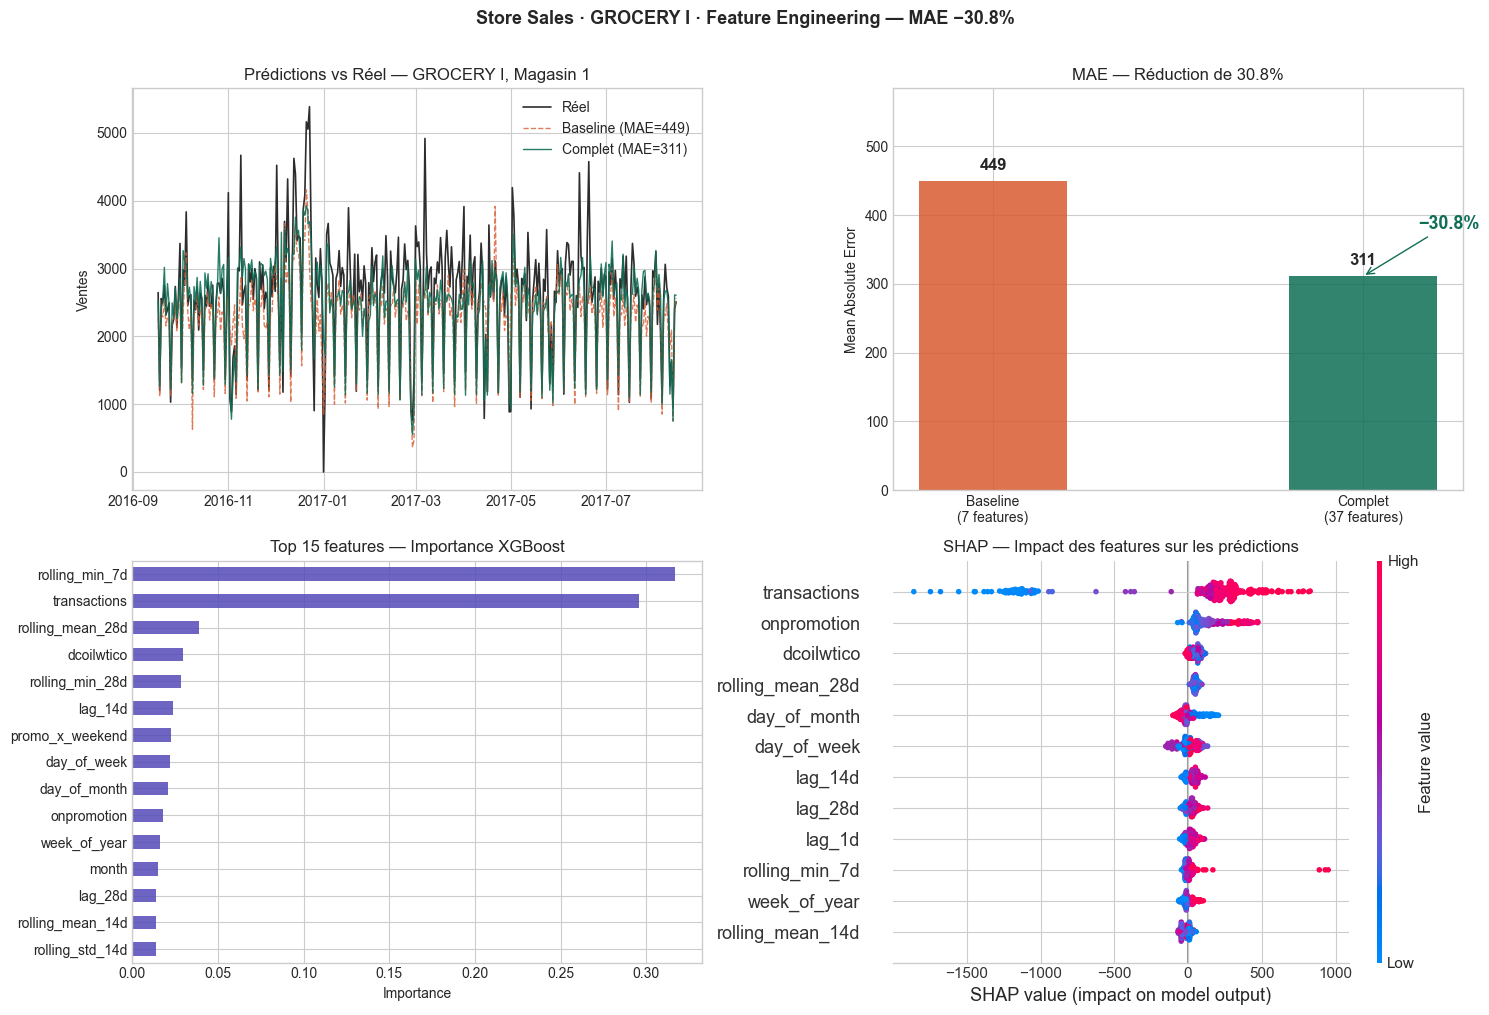

  → MAE Baseline  : 449
  → MAE Complet   : 311
  → Réduction     : −30.8%
  → Features      : 7 → 37


In [4]:

import shap

pred_full_vals = m_full.predict(X_test)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Graphique 1 : Prédictions vs Réel
axes[0,0].plot(y_test.index, y_test.values,
               label='Réel', color='#2d2d2d', linewidth=1.2)
axes[0,0].plot(y_test.index, pred_base,
               label=f'Baseline (MAE={mae_base:.0f})',
               color='#D85A30', linewidth=1, linestyle='--', alpha=0.8)
axes[0,0].plot(y_test.index, pred_full_vals,
               label=f'Complet (MAE={mae_full:.0f})',
               color='#0F6E56', linewidth=1, alpha=0.9)
axes[0,0].set_title('Prédictions vs Réel — GROCERY I, Magasin 1', fontsize=12)
axes[0,0].set_ylabel('Ventes')
axes[0,0].legend(fontsize=10)

# Graphique 2 : Résumé MAE
models  = ['Baseline\n(7 features)', 'Complet\n(37 features)']
maes    = [mae_base, mae_full]
colors  = ['#D85A30', '#0F6E56']
bars    = axes[0,1].bar(models, maes, color=colors, alpha=0.85, width=0.4)
axes[0,1].bar_label(bars, fmt='%.0f', padding=6, fontsize=12, fontweight='bold')
axes[0,1].set_title(f'MAE — Réduction de {reduction:.1f}%', fontsize=12)
axes[0,1].set_ylabel('Mean Absolute Error')
axes[0,1].set_ylim(0, mae_base * 1.3)

# Annotation réduction
axes[0,1].annotate(f'−{reduction:.1f}%',
                   xy=(1, mae_full), xytext=(1.15, (mae_base+mae_full)/2),
                   fontsize=13, fontweight='bold', color='#0F6E56',
                   arrowprops=dict(arrowstyle='->', color='#0F6E56'))

# Graphique 3 : Top 15 features importantes
feat_imp = pd.Series(m_full.feature_importances_, index=FEAT_COLS)
feat_imp.nlargest(15).sort_values().plot(
    kind='barh', ax=axes[1,0], color='#534AB7', alpha=0.85)
axes[1,0].set_title('Top 15 features — Importance XGBoost', fontsize=12)
axes[1,0].set_xlabel('Importance')

# Graphique 4 : SHAP summary
explainer  = shap.TreeExplainer(m_full)
shap_vals  = explainer(X_test)
shap.summary_plot(shap_vals, X_test, max_display=12,
                  show=False, plot_size=None)
plt.sca(axes[1,1])
axes[1,1].set_title('SHAP — Impact des features sur les prédictions', fontsize=12)

plt.suptitle(
    f'Store Sales · GROCERY I · Feature Engineering — MAE −{reduction:.1f}%',
    fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('resultats_feature_engineering.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  → MAE Baseline  : {mae_base:.0f}")
print(f"  → MAE Complet   : {mae_full:.0f}")
print(f"  → Réduction     : −{reduction:.1f}%")
print(f"  → Features      : 7 → 37")